In [1]:
%matplotlib inline
import pathlib as pl
import numpy as np
import sys
import xugrid
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import rasterio.warp
from shapely.geometry import shape

import scipy.sparse as sparse

import flopy
import flopy.plot.styles as styles

from gdptools import WeightGenP2P

c:\Users\bbayrakt\AppData\Local\miniforge3\envs\liss\lib\site-packages\gdptools\data\odap_cat_data.py:35: PydanticDeprecatedSince20: Pydantic V1 style `@validator` validators are deprecated. You should migrate to Pydantic V2 style `@field_validator` validators, see the migration guide for more details. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  @validator("grid_id", pre=True, always=True)
c:\Users\bbayrakt\AppData\Local\miniforge3\envs\liss\lib\site-packages\gdptools\data\odap_cat_data.py:40: PydanticDeprecatedSince20: Pydantic V1 style `@validator` validators are deprecated. You should migrate to Pydantic V2 style `@field_validator` validators, see the migration guide for more details. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  @validator("nT", pre=True, always=False)
c:\Users\bbayrakt\AppData\Local\miniforge3

In [2]:
sys.path.append("../common")
from liss_settings import cx, cx_provider, extent, boxx, boxy, get_dflow_grid_name, get_modflow_coupling_tag, get_modflow_grid_name

In [3]:
control_path = pl.Path("../dflow-fm/coarse/tides/base/FlowFM.mdu") # change this if using a different D-Flow FM control file
grid_name = get_dflow_grid_name(control_path)
print(grid_name)

LIS_LowRES_012026_net


In [4]:
mf_grid_name = get_modflow_grid_name()
print(mf_grid_name)

gp_chd


In [5]:
get_modflow_coupling_tag(1.)

'01.00H'

## Read the D-Flow FM output file

Make sure you run D-Flow FM by itself first so that there is an output NetCDF file available so that the mapping is done using the internal node order

In [6]:
# use an output file because this is what will be available from bmi and is in the correct order
source_path = control_path.parent / "FlowFM_map.nc"
source_ds = xugrid.open_dataset(source_path)

In [7]:
source_ds

<xarray.Dataset> Size: 53MB
Dimensions:                      (mesh2d_nNodes: 3600, mesh2d_nEdges: 10095,
                                  mesh2d_nFaces: 6491,
                                  mesh2d_nMax_face_nodes: 5, time: 54)
Coordinates:
    mesh2d_node_x                (mesh2d_nNodes) float64 29kB ...
    mesh2d_node_y                (mesh2d_nNodes) float64 29kB ...
    mesh2d_edge_x                (mesh2d_nEdges) float64 81kB ...
    mesh2d_edge_y                (mesh2d_nEdges) float64 81kB ...
    mesh2d_face_x                (mesh2d_nFaces) float64 52kB ...
    mesh2d_face_y                (mesh2d_nFaces) float64 52kB ...
  * time                         (time) datetime64[ns] 432B 2010-01-01 ... 20...
  * mesh2d_nEdges                (mesh2d_nEdges) int64 81kB 0 1 ... 10093 10094
  * mesh2d_nNodes                (mesh2d_nNodes) int64 29kB 0 1 2 ... 3598 3599
  * mesh2d_nFaces                (mesh2d_nFaces) int64 52kB 0 1 2 ... 6489 6490
Dimensions without coordinates: mesh2d_nMax_face_nodes
Data variables: (12/23)
    projected_coordinate_system  int32 4B ...
    mesh2d_node_z                (mesh2d_nNodes) float64 29kB ...
    mesh2d_face_x_bnd            (mesh2d_nFaces, mesh2d_nMax_face_nodes) float64 260kB ...
    mesh2d_face_y_bnd            (mesh2d_nFaces, mesh2d_nMax_face_nodes) float64 260kB ...
    mesh2d_edge_type             (mesh2d_nEdges) float64 81kB ...
    mesh2d_flowelem_ba           (mesh2d_nFaces) float64 52kB ...
    ...                           ...
    mesh2d_q1                    (time, mesh2d_nEdges) float64 4MB ...
    mesh2d_viu                   (time, mesh2d_nEdges) float64 4MB ...
    mesh2d_diu                   (time, mesh2d_nEdges) float64 4MB ...
    mesh2d_taus                  (time, mesh2d_nFaces) float64 3MB ...
    mesh2d_czs                   (time, mesh2d_nFaces) float64 3MB ...
    mesh2d_czu                   (time, mesh2d_nEdges) float64 4MB ...
Attributes:
    institution:    Deltares
    references:     http://www.deltares.nl
    source:         D-Flow FM 1.2.123.69078M. Model:
    history:        Created on 2026-05-19T10:25:29-0400, D-Flow FM
    date_created:   2026-05-19T10:25:29-0400
    date_modified:  2026-05-19T10:25:29-0400
    Conventions:    CF-1.8 UGRID-1.0 Deltares-0.10

In [8]:
print(source_ds.grid.face_node_connectivity.shape)
source_ds.grid.face_node_connectivity

(6491, 5)


array([[   1,    2,    0, -999, -999],
       [   1,    0,    3, -999, -999],
       [   4,    2,    1, -999, -999],
       ...,
       [3528, 3527, 3530, 3598, -999],
       [3529, 3531, 3527, 3524, -999],
       [3531, 3599, 3530, 3527, -999]], dtype=int64)

In [9]:
print(source_ds.grid.node_face_connectivity.shape)
source_ds.grid.node_face_connectivity

(3600, 6491)


<3600x6491 sparse matrix of type '<class 'numpy.int32'>'
	with 19556 stored elements in Compressed Sparse Row format>

### Convert the NetCDF data to a geodataframe

In [10]:
source_gdf = source_ds["mesh2d_nFaces"].ugrid.to_geodataframe(name="cell")

In [11]:
source_gdf.set_crs(32618, inplace=True)

,cell,mesh2d_face_x,mesh2d_face_y,geometry
mesh2d_nFaces,,,,
0,0,797898.154301,4.586507e+06,"POLYGON ((796404.975 4587306.686, 797841.614 4..."
1,1,797924.131967,4.588199e+06,"POLYGON ((796404.975 4587306.686, 799415.174 4..."
2,2,796394.352412,4.585640e+06,"POLYGON ((795260.176 4584419.699, 797841.614 4..."
3,3,799053.495508,4.585764e+06,"POLYGON ((797841.614 4584814.613, 800431.665 4..."
4,4,796629.376272,4.584104e+06,"POLYGON ((795260.176 4584419.699, 796708.901 4..."
...,...,...,...,...
6486,6486,591402.468816,4.551570e+06,"POLYGON ((589715.163 4549828.040, 592370.304 4..."
6487,6487,593237.204364,4.547120e+06,"POLYGON ((594377.970 4545125.166, 595025.445 4..."
6488,6488,591856.393641,4.555221e+06,"POLYGON ((590265.916 4553488.914, 593058.725 4..."


## Open the shapefile with the location of the coastal boundaries in MODFLOW

The shapefile needs to be limited to coastal boundary locations and be in the same coordinate system as the D-Flow FM model (UTM 18N).

In [12]:
fpth = f"../modflow/gis/gp/{mf_grid_name}_ghb_utm18n.shp"
print(fpth)

../modflow/gis/gp/gp_chd_ghb_utm18n.shp


In [13]:
target_coastal = gpd.read_file(fpth) # this is the shapefile with coastal boundary conditions
target_coastal

,head,cond,salinity,boundname,layer,row,column,ghb_no,geometry
0,0.234,4835.190,27.119,wetland,0,11,53,0,"POLYGON ((723969.935 4557362.289, 724114.352 4..."
1,0.234,4734.790,27.119,wetland,0,11,54,1,"POLYGON ((724114.352 4557411.074, 724258.770 4..."
2,0.234,4173.495,27.119,wetland,0,12,53,2,"POLYGON ((724018.720 4557217.870, 724163.138 4..."
3,0.234,5556.300,27.119,wetland,0,12,54,3,"POLYGON ((724163.138 4557266.655, 724307.556 4..."
4,0.234,4906.405,27.119,wetland,0,13,52,4,"POLYGON ((723923.088 4557024.666, 724067.506 4..."
...,...,...,...,...,...,...,...,...,...
67,0.234,4709.165,27.119,wetland,0,41,10,67,"POLYGON ((719223.708 4550932.033, 719368.118 4..."
68,0.234,5475.300,27.119,wetland,0,41,11,68,"POLYGON ((719368.118 4550980.813, 719512.529 4..."
69,0.234,4807.035,27.119,wetland,0,42,10,69,"POLYGON ((719272.481 4550787.617, 719416.891 4..."
70,0.234,4477.235,27.119,wetland,0,42,11,70,"POLYGON ((719416.891 4550836.397, 719561.302 4..."


In [14]:
target_coastal.crs

<Projected CRS: EPSG:32618>
Name: WGS 84 / UTM zone 18N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 78°W and 72°W, northern hemisphere between equator and 84°N, onshore and offshore. Bahamas. Canada - Nunavut; Ontario; Quebec. Colombia. Cuba. Ecuador. Greenland. Haiti. Jamaica. Panama. Turks and Caicos Islands. United States (USA). Venezuela.
- bounds: (-78.0, 0.0, -72.0, 84.0)
Coordinate Operation:
- name: UTM zone 18N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

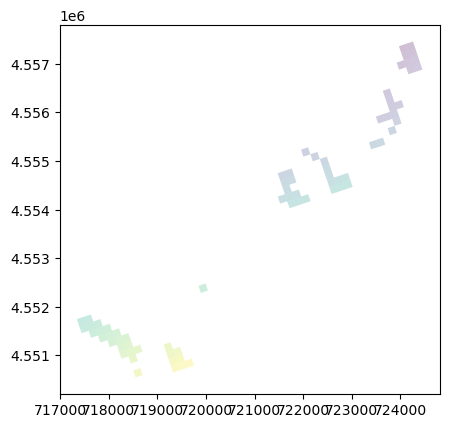

In [15]:
ax = target_coastal.plot(alpha=0.25, column="ghb_no")
#cx.add_basemap(ax, crs=target_coastal.crs, attribution=False, source=cx_provider)

## Create the D-FLOW FM to GHB mapping

In [16]:
# generate the weights
weight_gen = WeightGenP2P(
    target_poly=target_coastal,
    target_poly_idx="ghb_no",
    source_poly=source_gdf,
    source_poly_idx=["cell"],
    method="serial",
    weight_gen_crs=32618,
)
weights = weight_gen.calculate_weights()

Using serial engine
Reprojecting to epsg:EPSG:32618 finished in 0.0 second(s)
Validating polygons
     - validating source polygons
     - fixing 0 invalid polygons.
     - validating target polygons
     - fixing 0 invalid polygons.
Validate polygons finished in 0.0102 seconds
Intersections finished in 0.0034 seconds
Weight gen finished in 0.0139 seconds


In [17]:
weights[:12]

,ghb_no,cell,wght
0,0,1557,1.000000
1,1,1557,0.647337
2,1,1506,0.352663
3,2,1557,1.000000
4,3,1557,0.682919
5,3,1506,0.317081
6,4,1557,1.000000
7,5,1557,1.000000
8,6,1557,0.718501
9,6,1506,0.281499


In [18]:
map_shape = (target_coastal.shape[0], source_gdf.shape[0])
map_shape

(72, 6491)

In [19]:
dflow2mfghb = np.zeros(map_shape, dtype=float)
print(f"{dflow2mfghb.shape}\n{dflow2mfghb}")

(72, 6491)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [20]:
for r,c,v in zip(weights["ghb_no"], weights["cell"], weights["wght"]):
    dflow2mfghb[int(r),int(c)] = v

## Create the ghb masking array

Where the sums of the weights along a row are not equal to ~1.0

In [21]:
mask_idx = np.isclose(dflow2mfghb.sum(axis=1), 1.0)
print(f"{mask_idx.sum()}\n{mask_idx.shape}\n{mask_idx}")

72
(72,)
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True]


### Test the D-FLOW FM to GHB mapping

In [22]:
s = np.full(source_gdf.shape[0], 1.0)
h = np.full(mask_idx.shape, 2.0)
h[mask_idx] = dflow2mfghb.dot(s)[mask_idx]
s.shape, dflow2mfghb.shape, h.shape

((6491,), (72, 6491), (72,))

In [23]:
print(f"{h.sum()}\n{h}")

72.0000000000002
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


#### Test with a nan

In [24]:
s = np.random.random(source_gdf.shape[0])
s[1544] = -1e30
print(s)

[0.30045409 0.68933706 0.31970324 ... 0.98856006 0.81473993 0.65761023]


In [25]:
h = np.full(mask_idx.shape, 2.0)
h = dflow2mfghb.dot(s)
h.shape

(72,)

In [26]:
print(f"{h.sum()}\n{h}")

28.271762473456704
[0.84923597 0.75168141 0.84923597 0.7615241  0.84923597 0.84923597
 0.77136699 0.84923597 0.78121009 0.09790561 0.09790561 0.09790561
 0.09790561 0.09790561 0.09790561 0.09790561 0.55565932 0.09790561
 0.55565932 0.09790561 0.55565932 0.55565932 0.55565932 0.09790561
 0.09790561 0.55565932 0.55565932 0.55565932 0.55565932 0.55565932
 0.61374846 0.55975495 0.55565932 0.55565932 0.55565932 0.33642127
 0.69520564 0.630576   0.56762456 0.55565932 0.55565932 0.39448158
 0.13970612 0.13970612 0.13970612 0.13970612 0.13970612 0.19954605
 0.13970612 0.13970612 0.13970612 0.13970612 0.13970612 0.13970612
 0.13970612 0.13970612 0.15231885 0.17319673 0.34288228 0.3667222
 0.38448371 0.38448371 0.38448371 0.38448371 0.38448371 0.40717786
 0.38448371 0.38448371 0.39921772 0.38448371 0.39125756 0.42576769]


## Create the GHB to Qext mapping

In [27]:
ghb2qext = np.transpose(dflow2mfghb.copy())

### Test the GHB to Qext mapping

In [28]:
q = np.full(ghb2qext.shape[1], 1.0)

In [29]:
qext = ghb2qext.dot(q)

In [30]:
print(f"{qext.sum()}\n{qext.shape}")

72.0000000000002
(6491,)


## Save the mapping arrays

In [31]:
fpath = f"../mapping/gp/dflow_{grid_name}_to_{mf_grid_name}_ghb.npz"
np.savez_compressed(fpath, dflow2mfghb=dflow2mfghb, ghbmask=mask_idx, ghb2qext=ghb2qext)